# Chapter 5 — Wavelets & Other Transforms

### Companion notebook · *Biomedical Signal Processing & Data Analytics*

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/farhad-abtahi/CM2013/blob/main/notebooks/ch05_wavelets_transforms.ipynb) [![View](https://img.shields.io/badge/view-static-orange)](https://farhad-abtahi.github.io/CM2013/nb/ch05_wavelets_transforms.html) [![JupyterLite](https://img.shields.io/badge/run-JupyterLite-blue)](https://farhad-abtahi.github.io/CM2013/lite/lab/index.html?path=ch05_wavelets_transforms.ipynb)

> **Motivating question.** When a single spectrum is not enough — how do we localize a transient K-complex in time and frequency?

## What this notebook demonstrates

- Multiresolution time–frequency tiling (tall-thin vs short-wide)
- DWT levels mapped to EEG bands; the Hilbert envelope for EMG
- 2-D DWT subband pyramid (LL/LH/HL/HH) on an image
- Inverse transform & perfect reconstruction
- Wavelet compression & denoising

## What you'll do

You'll localize a K-complex with the DWT and check which decomposition level it lands on, pull an EMG envelope out with the Hilbert transform, and run wavelet compression and denoising on a 2-D image via its subbands.

## Runs in

| Platform | Status |
|---|---|
| **View (static)** | view only — outputs are pre-rendered |
| **Google Colab** | full, recommended |
| **JupyterLite** | reduced (a lighter path runs in the browser) |

**Data:** synthetic & reproducible (`SEED = 0`).  
**Runtime:** CPU, a few minutes.  
*All numbers below are illustrative and reproducible — not clinical benchmarks.*

In [1]:
%matplotlib inline
import sys, os, subprocess

# --- get the shared modules (bookstyle, biosignals, and the bsp package) ---
# Local repo checkout: they sit in ../src (package) and ../src/bsp (modules).
# Colab / JupyterLite: clone the repo once.
for c in ("src", "../src", "src/bsp", "../src/bsp"):
    if os.path.isdir(c):
        sys.path.insert(0, os.path.abspath(c))
try:
    import bookstyle as bs, biosignals as bio
    from bsp.loaders import setup
except Exception:
    if "google.colab" in sys.modules:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                        "pywavelets", "scikit-learn"], check=False)
    subprocess.run(["git", "clone", "--depth", "1",
                    "https://github.com/farhad-abtahi/CM2013", "_bsp_repo"], check=False)
    for c in ("_bsp_repo/src", "_bsp_repo/src/bsp"):
        sys.path.insert(0, os.path.abspath(c))
    import bookstyle as bs, biosignals as bio
    from bsp.loaders import setup

import numpy as np
import matplotlib.pyplot as plt
from bsp.loaders import setup
SEED = 0
rng = setup(SEED)     # fixes the seed; all synthetic data below is reproducible


environment : local
seed        : 0  (all synthetic data is reproducible)


## Setup: imports and shared helpers

These are the same building blocks the book's figures use; read them once, then reuse.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from scipy.signal import hilbert
import pywt

CH = 5

## 5.1 Time–frequency tiling: STFT vs wavelet

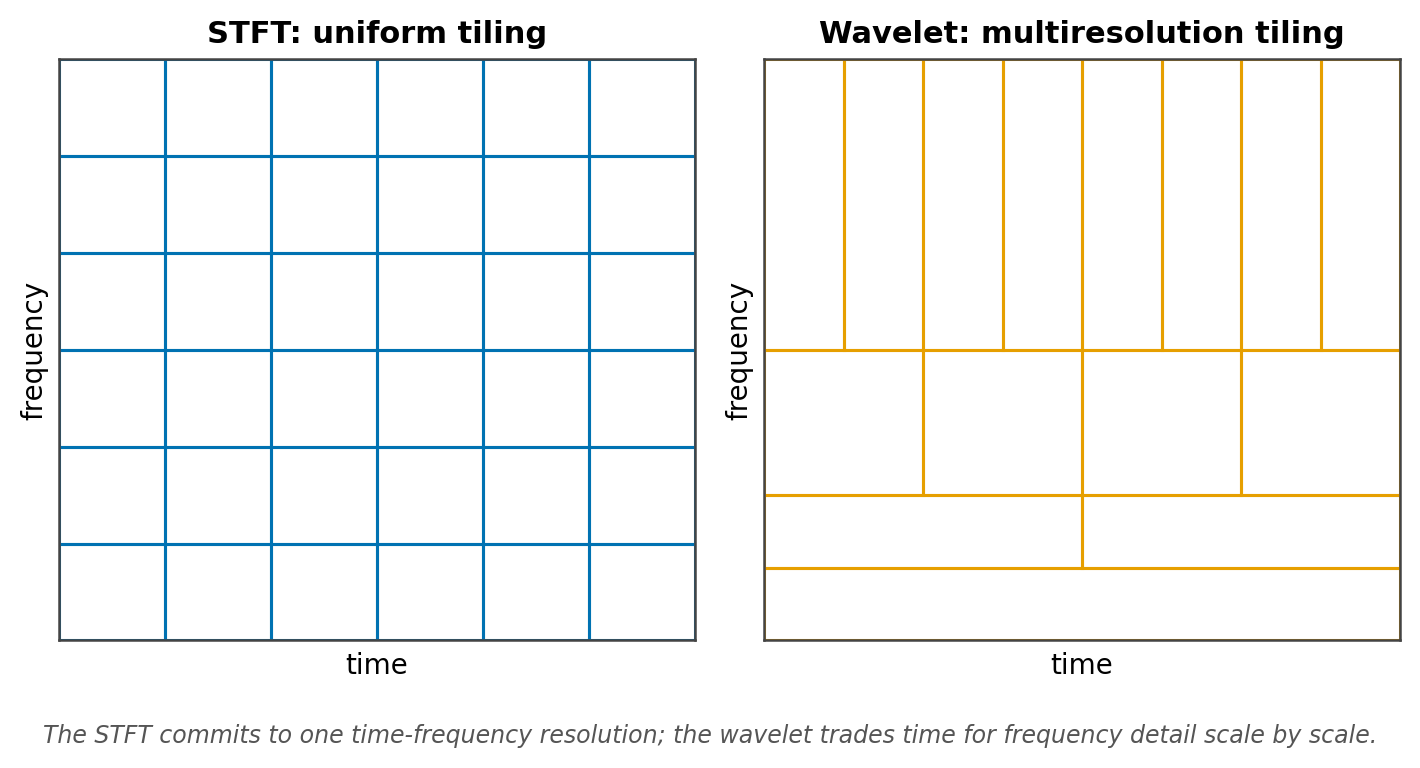

In [3]:
fig, axes = bs.newfig(w=7.2, h=3.6, ncols=2)

# --- STFT: uniform rectangular tiles (fixed window -> fixed dt, df) ---
axS = axes[0]
nt, nf = 6, 6
for i in range(nt):
    for j in range(nf):
        axS.add_patch(Rectangle((i / nt, j / nf), 1 / nt, 1 / nf,
                                fill=False, edgecolor=bs.C['blue'],
                                linewidth=1.1))
axS.set_title("STFT: uniform tiling")
axS.set_xlabel("time"); axS.set_ylabel("frequency")
axS.set_xlim(0, 1); axS.set_ylim(0, 1)
axS.set_xticks([]); axS.set_yticks([]); axS.grid(False)

# --- Wavelet: TALL-THIN tiles at HIGH freq (fine time, coarse freq),
#     SHORT-WIDE tiles at LOW freq (coarse time, fine freq). Frequency
#     increases upward; equal-area dyadic (octave) tiling.
axW = axes[1]
# from the TOP (highest octave) down to the low-frequency approximation
heights = [0.5, 0.25, 0.125, 0.125]   # high-freq band is tallest
ncols = [8, 4, 2, 1]                   # and split into the most time tiles
y_top = 1.0
for h, n_tiles in zip(heights, ncols):
    y0 = y_top - h
    y_top = y0
    w = 1.0 / n_tiles
    for k in range(n_tiles):
        axW.add_patch(Rectangle((k * w, y0), w, h, fill=False,
                                edgecolor=bs.C['orange'], linewidth=1.1))
axW.set_title("Wavelet: multiresolution tiling")
axW.set_xlabel("time"); axW.set_ylabel("frequency")
axW.set_xlim(0, 1); axW.set_ylim(0, 1)
axW.set_xticks([]); axW.set_yticks([]); axW.grid(False)

bs.takeaway(fig, "The STFT commits to one time-frequency resolution; the "
                 "wavelet trades time for frequency detail scale by scale.")
plt.tight_layout()
plt.show()

## 5.2 DWT localizes a K-complex; Hilbert envelope of EMG

In [ ]:
fig, axes = bs.newfig(w=7.2, h=6.6, nrows=4, ncols=2)

# ---- LEFT COLUMN: 1-D DWT of an EEG N2 epoch (localize the K-complex) ----
fs = 100.0
t, x = bio.eeg(duration=30.0, fs=fs, stage="N2")
# Take a short window centred on the K-complex (~9 s) for clarity.
c = 30.0 * 0.30
m = (t >= c - 2.0) & (t <= c + 2.0)
tt, xx = t[m], x[m]

wavelet = "db4"
coeffs = pywt.wavedec(xx, wavelet, level=4)
cA4, cD4, cD3, cD2, cD1 = coeffs

# Perfect-reconstruction check: the DWT is invertible, so re-assembling all
# bands with waverec must return (numerically) the original signal.
print("PR error:", np.max(np.abs(pywt.waverec(coeffs, wavelet)[:len(xx)] - xx)))

axL = axes[:, 0]
axL[0].plot(tt, xx, color=bs.C['blue'], lw=1.0)
axL[0].axvline(c, color=bs.C['red'], ls='--', lw=1.0)
axL[0].set_title("EEG N2 epoch (K-complex marked)")
axL[0].set_ylabel("amp")

# Reconstruct each band on the ORIGINAL time axis via a true single-band
# inverse DWT (zero every other band, then waverec) so the plotted curve
# is the band's actual contribution at the right times -- plotting the
# raw, decimated coefficient array against a fabricated linspace instead
# mislocalizes any feature relative to the original signal.
def _isolate(keep_idx):
    zeroed = [c if i == keep_idx else np.zeros_like(c) for i, c in enumerate(coeffs)]
    return pywt.waverec(zeroed, wavelet)[:len(xx)]

labels = [("D1 (~25-50 Hz)", _isolate(4)), ("D2 (~12-25 Hz)", _isolate(3)),
          ("A4 (~<3 Hz, slow)", _isolate(0))]
cols = [bs.C['green'], bs.C['orange'], bs.C['purple']]
for ax, (lab, c_arr), col in zip(axL[1:], labels, cols):
    ax.plot(tt, c_arr, color=col, lw=1.0)
    ax.set_ylabel(lab, fontsize=8)
    ax.axvline(c if 'A4' in lab else tt[np.argmax(np.abs(c_arr))],
               color=bs.C['red'], ls=':', lw=0.8)
    if 'A4' not in lab:
        # The dotted line marks THIS band's own argmax, not the K-complex --
        # for a fast detail band that peak can sit far from the K-complex
        # instant marked with the dashed red line in panel (a).
        ax.text(0.98, 0.85, "dotted = this band's max", transform=ax.transAxes,
                ha="right", fontsize=7)
axL[-1].set_xlabel("time (s)")
axL[0].text(0.02, 0.9, "(a)", transform=axL[0].transAxes, fontweight='bold')

# ---- RIGHT COLUMN: Hilbert envelope of an EMG burst ----
fse = 1000.0
te, xe = bio.emg_burst(duration=5.0, fs=fse)
analytic = hilbert(xe)
env = np.abs(analytic)

axR = axes[:, 1]
axR[0].plot(te, xe, color=bs.C['grey'], lw=0.5)
axR[0].set_title("sEMG burst signal")
axR[0].set_ylabel("amp")
axR[0].text(0.02, 0.9, "(b)", transform=axR[0].transAxes, fontweight='bold')

axR[1].plot(te, xe, color=bs.C['lightgrey'], lw=0.4)
axR[1].plot(te, env, color=bs.C['red'], lw=1.2)
axR[1].set_title("Hilbert envelope |analytic|")
axR[1].set_ylabel("amp")

inst_phase = np.unwrap(np.angle(analytic))
inst_freq = np.diff(inst_phase) / (2 * np.pi) * fse
axR[2].plot(te[1:], np.clip(inst_freq, 0, 400), color=bs.C['sky'], lw=0.4)
axR[2].set_ylabel("inst. f (Hz)", fontsize=8)
axR[2].set_title("inst. f -- meaningless here (broadband; see Lab 5)", fontsize=8)
axR[2].set_ylim(0, 400)

# A smoothed activation-detection trace from the envelope.
from scipy.ndimage import uniform_filter1d
smooth = uniform_filter1d(env, int(0.1 * fse))
thr = 0.5 * np.max(smooth)
axR[3].plot(te, smooth, color=bs.C['orange'], lw=1.0)
axR[3].axhline(thr, color=bs.C['red'], ls='--', lw=0.9)
axR[3].fill_between(te, 0, smooth, where=smooth > thr,
                    color=bs.C['orange'], alpha=0.2)
axR[3].set_ylabel("activation", fontsize=8)
axR[3].set_xlabel("time (s)")

bs.takeaway(fig, "One mechanism, two jobs: the DWT localizes the K-complex "
                 "in the slow band while the Hilbert envelope turns an EMG "
                 "burst into an activation trace.")
plt.tight_layout()
plt.show()

## 5.3 2-D DWT subband pyramid

In [ ]:
img = bio.test_photo(256)
wavelet = "db2"
level = 3

# Multi-level 2-D DWT: coeffs = [LL, (LH3,HL3,HH3), (LH2,HL2,HH2), (LH1,HL1,HH1)]
coeffs = pywt.wavedec2(img, wavelet, level=level)

# Assemble the classic pyramid mosaic. We normalise each band for display:
# the coarse LL keeps its own scale; detail bands are log-stretched so the
# faint high-level edges remain visible next to the strong low-level ones.
arr, slices = pywt.coeffs_to_array(coeffs)
mosaic = np.zeros_like(arr)

# LL block (approximation) — linear stretch to [0,1].
ll = arr[slices[0]]
mosaic[slices[0]] = (ll - ll.min()) / (ll.max() - ll.min() + 1e-9)

# Detail blocks — log-scaled magnitude for visibility.
# pywt's 'ad' key (approx-rows x detail-cols) holds the VERTICAL-detail
# coefficients (cV) and sits top-right; 'da' (detail-rows x approx-cols)
# holds HORIZONTAL-detail (cH) and sits bottom-left -- i.e. 'ad' is HL and
# 'da' is LH per the book's "LH/HL/HH hold horizontal/vertical/diagonal
# detail" convention (verified via pywt.coeffs_to_array on synthetic
# horizontal- and vertical-line test images).
for lev in slices[1:]:
    for key in ("ad", "da", "dd"):          # HL, LH, HH
        sl = lev[key]
        d = np.abs(arr[sl])
        d = np.log1p(d)
        d = d / (d.max() + 1e-9)
        mosaic[sl] = d

fig, ax = bs.newfig(w=6.6, h=6.6)
ax.imshow(mosaic, cmap="gray", vmin=0, vmax=1)
ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
ax.set_title(f"3-level 2-D wavelet decomposition ('{wavelet}')")

# Overlay the pyramid geometry and subband labels.
N = arr.shape[0]
# Boundaries between levels: read the REAL slice boundaries pywt.coeffs_to_array
# returns rather than assuming the LL block doubles cleanly each step -- for a
# 256px/db2/3-level decomposition the true boundaries are off by a couple of
# pixels from that idealised doubling because of the wavelet's filter length.
bounds = [slices[0][0].stop] + [lev["dd"][0].stop for lev in slices[1:-1]]
for b in bounds:
    ax.axhline(b - 0.5, color=bs.C["orange"], lw=1.0)
    ax.axvline(b - 0.5, color=bs.C["orange"], lw=1.0)

ll_size = slices[0][0].stop
ax.text(ll_size * 0.5, ll_size * 0.5, "LL", color=bs.C["sky"],
        ha="center", va="center", fontsize=11, fontweight="bold")
# Label the detail triple at each level (HL top-right, LH bottom-left, HH bot-right)
prev = 0
for b in bounds:
    mid_lo = (prev + b) / 2
    mid_hi = (b + (bounds[bounds.index(b) + 1] if bounds.index(b) + 1 < len(bounds) else N)) / 2
    ax.text(mid_hi, mid_lo, "HL", color=bs.C["orange"], ha="center",
            va="center", fontsize=8, fontweight="bold")
    ax.text(mid_lo, mid_hi, "LH", color=bs.C["orange"], ha="center",
            va="center", fontsize=8, fontweight="bold")
    ax.text(mid_hi, mid_hi, "HH", color=bs.C["orange"], ha="center",
            va="center", fontsize=8, fontweight="bold")
    prev = b

bs.takeaway(fig, "Multi-level (multiresolution) 2-D wavelet transform: the "
                 "tiny LL thumbnail at the top-left holds the coarse image, "
                 "while LH/HL/HH detail bands at every scale light up on the "
                 "photo's edges (horizontal, vertical, diagonal).")
plt.tight_layout()
plt.show()

## 5.4 Wavelet compression and denoising

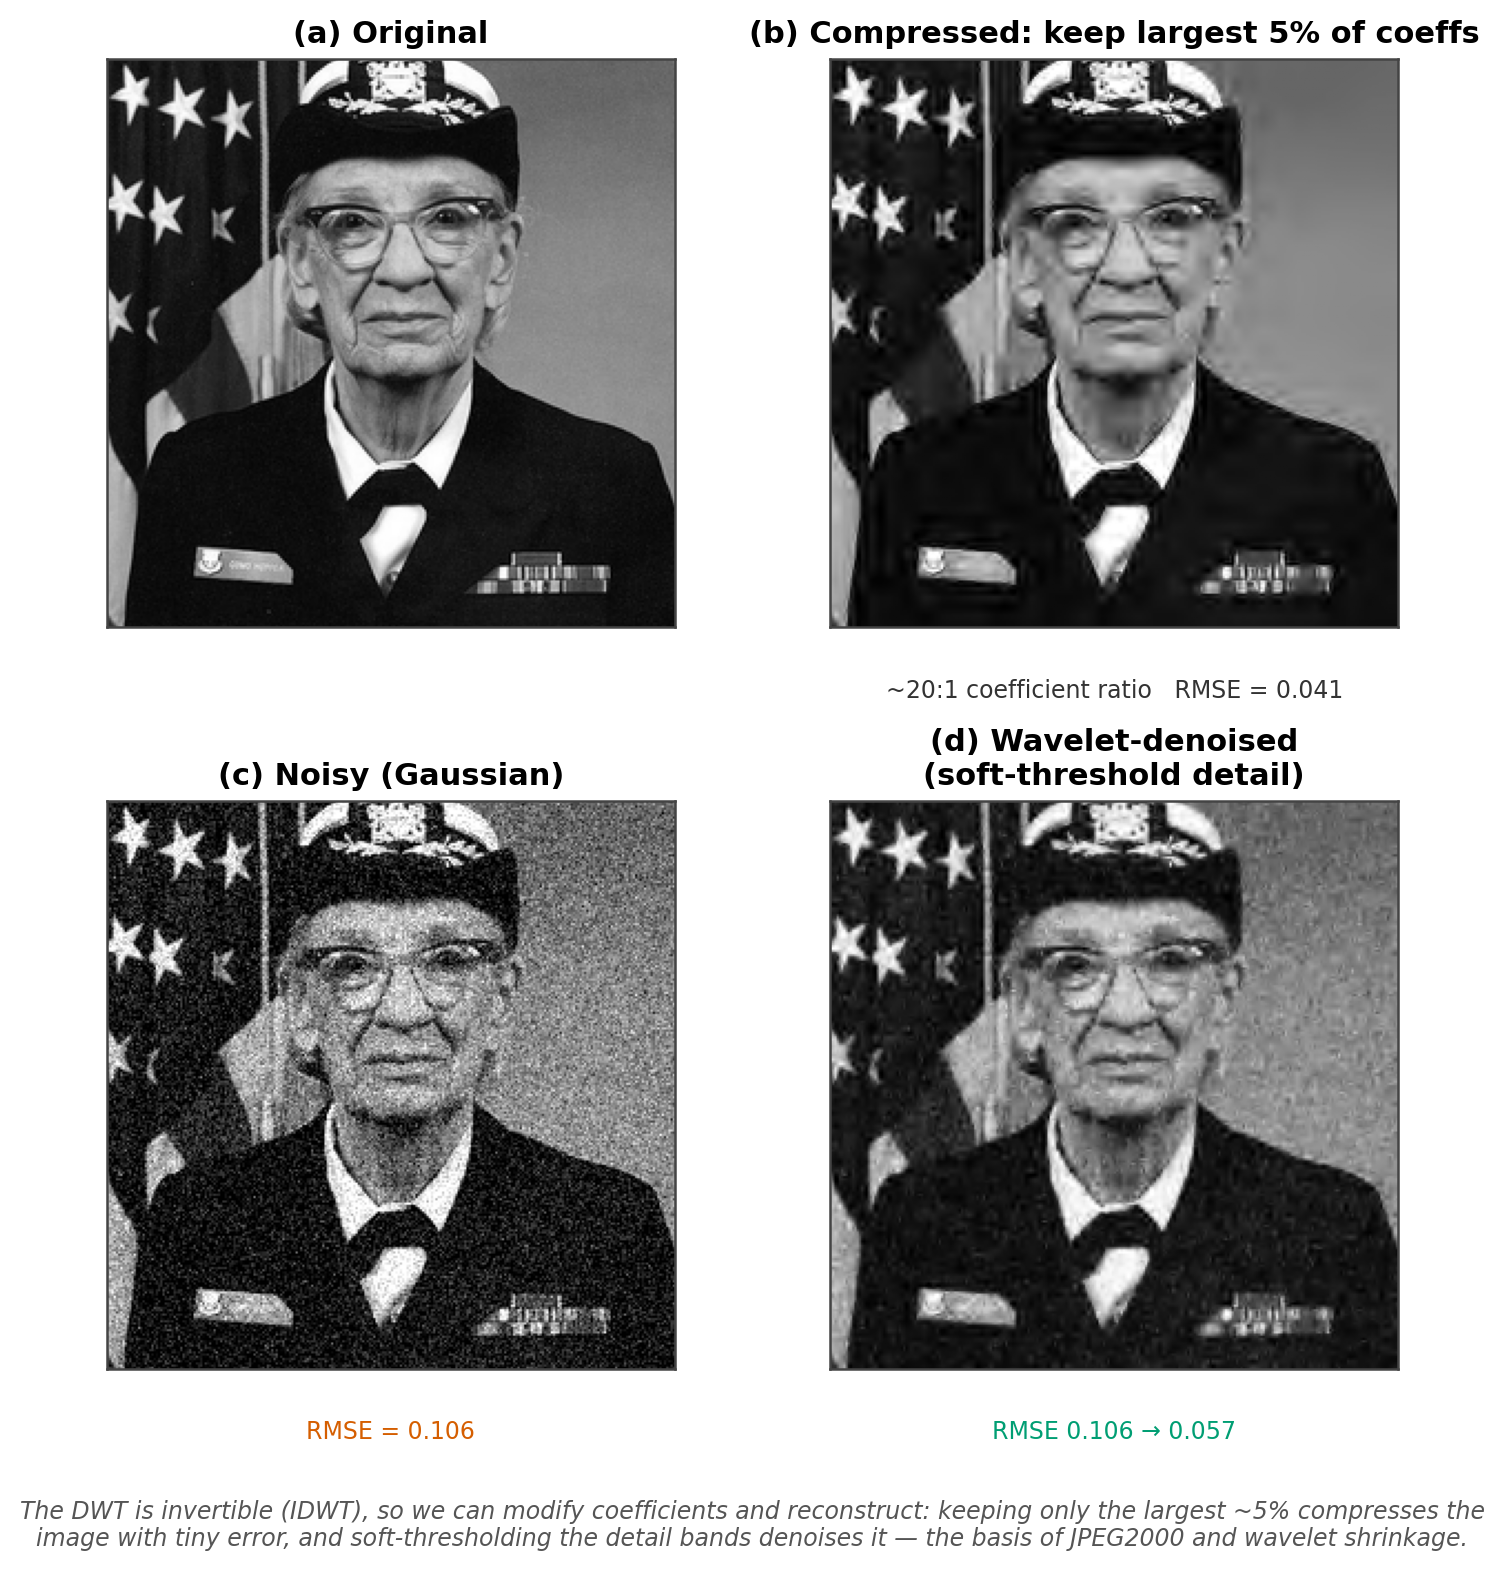

In [6]:
img = bio.test_photo(256)
wavelet = "sym4"          # smooth, near-symmetric — good for photographs
level = 4

def rmse(a, b):
    return float(np.sqrt(np.mean((a - b) ** 2)))

# ---- (b) COMPRESSION: keep only the largest ~5% of wavelet coefficients ----
coeffs = pywt.wavedec2(img, wavelet, level=level)
arr, slices = pywt.coeffs_to_array(coeffs)
flat = np.abs(arr).ravel()
keep_frac = 0.05
n_keep = int(keep_frac * flat.size)
thresh = np.sort(flat)[-n_keep]             # keep-largest threshold
arr_c = arr * (np.abs(arr) >= thresh)       # zero the small coefficients
coeffs_c = pywt.array_to_coeffs(arr_c, slices, output_format="wavedec2")
recon_c = pywt.waverec2(coeffs_c, wavelet)
recon_c = recon_c[:img.shape[0], :img.shape[1]]
kept = np.count_nonzero(arr_c) / arr.size
err_c = rmse(img, recon_c)

# ---- (c) NOISY version ----
noisy = bio.add_gaussian_image(img, sigma=0.12)
rmse_noisy = rmse(img, noisy)

# ---- (d) DENOISING: soft-threshold the detail coefficients, reconstruct ----
c_noisy = pywt.wavedec2(noisy, wavelet, level=level)
# Robust noise estimate from the finest diagonal detail (median / MAD rule).
hh1 = c_noisy[-1][2]
sigma_hat = np.median(np.abs(hh1)) / 0.6745
# BayesShrink-style, level-adaptive soft threshold. The universal
# sqrt(2 log N) threshold is too aggressive for a photograph (it oversmooths
# and barely improves RMSE); a per-subband threshold that scales with the
# noise floor removes the grain while keeping edges.
def shrink(d):
    var_y = np.mean(d ** 2)
    sigma_x = np.sqrt(max(var_y - sigma_hat ** 2, 1e-8))
    thr = sigma_hat ** 2 / sigma_x            # BayesShrink threshold
    return pywt.threshold(d, thr, mode="soft")
c_den = [c_noisy[0]]                           # keep approximation untouched
for detail in c_noisy[1:]:
    c_den.append(tuple(shrink(d) for d in detail))
recon_d = pywt.waverec2(c_den, wavelet)
recon_d = recon_d[:img.shape[0], :img.shape[1]]
rmse_den = rmse(img, recon_d)

fig, axes = bs.newfig(w=7.4, h=7.4, nrows=2, ncols=2)
for ax in axes.ravel():
    ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)

axes[0, 0].imshow(img, cmap="gray", vmin=0, vmax=1)
axes[0, 0].set_title("(a) Original")

axes[0, 1].imshow(np.clip(recon_c, 0, 1), cmap="gray", vmin=0, vmax=1)
axes[0, 1].set_title("(b) Compressed: keep largest "
                     f"{kept*100:.0f}% of coeffs")
axes[0, 1].text(0.5, -0.09,
                f"~{1/keep_frac:.0f}:1 coefficient ratio   RMSE = {err_c:.3f}",
                transform=axes[0, 1].transAxes, ha="center", va="top",
                fontsize=8.5, color="#333333")

axes[1, 0].imshow(np.clip(noisy, 0, 1), cmap="gray", vmin=0, vmax=1)
axes[1, 0].set_title("(c) Noisy (Gaussian)")
axes[1, 0].text(0.5, -0.09, f"RMSE = {rmse_noisy:.3f}",
                transform=axes[1, 0].transAxes, ha="center", va="top",
                fontsize=8.5, color=bs.C["red"])

axes[1, 1].imshow(np.clip(recon_d, 0, 1), cmap="gray", vmin=0, vmax=1)
axes[1, 1].set_title("(d) Wavelet-denoised\n(soft-threshold detail)")
axes[1, 1].text(0.5, -0.09,
                f"RMSE {rmse_noisy:.3f} → {rmse_den:.3f}",
                transform=axes[1, 1].transAxes, ha="center", va="top",
                fontsize=8.5, color=bs.C["green"])

bs.takeaway(fig, "The DWT is invertible (IDWT), so we can modify coefficients "
                 "and reconstruct: keeping only the largest ~5% compresses the "
                 "image with tiny error, and soft-thresholding the detail bands "
                 "denoises it — the basis of JPEG2000 and wavelet shrinkage.")
plt.tight_layout()
plt.show()

## Expected outputs (reproducibility)

Because `SEED = 0`, re-running reproduces the figures above exactly. Change a parameter and watch them move — that loop between the page and the running code is where the intuition forms.

## MATLAB equivalent

The worked code here is Python-primary. The nearest MATLAB calls:

> `wavedec(x,4,'db4')`; `hilbert(x)`. (CWT: see Lab 5)

## Student tasks


For each task: **predict** the change first, **run** it, then **explain** the number you get. Use the workspace cell below (or duplicate a figure cell and edit it). Each task has a collapsible **hint** — commit your prediction *before* you open it.


**1.** Change `level=4` to `3` and `5`, and `'db4'` to `'haar'`. Which band (D_j or A_L) shows the K-complex most clearly? Give that band's Hz range using `[fs/2^(j+1), fs/2^j]`.

<details><summary>💡 Hint &amp; what you should see</summary>

A K-complex is a ~0.5–1 s low-frequency transient → it lands in the **coarser** DWT detail levels, **localized in time** (unlike the FFT, which loses the 'when').

</details>

**2.** Sweep `keep_frac` over 0.01, 0.02, 0.05, 0.10, 0.20 and tabulate RMSE. Below which fraction does RMSE exceed 0.05?

<details><summary>💡 Hint &amp; what you should see</summary>

Wavelets compact energy into a few large coefficients, so keeping 5 % reconstructs with **small** error (a few % RMS) — that is why wavelet compression/denoising works.

</details>

In [7]:
# Your workspace — attempt the tasks above.
# Tip: copy a figure cell, change ONE parameter, predict, then re-run.


---
*Companion notebook for **Biomedical Signal Processing & Data Analytics: From Physiology to Machine Learning**. Synthetic data; illustrative numbers. Generated from `figures_src/ch05_figures.py`.*